Image dimensions: (4096, 4096)
Telescope info from header: SPoCA


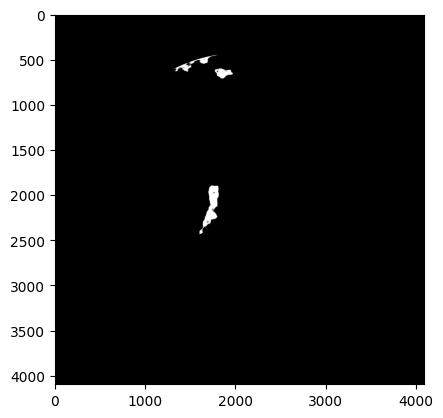

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt

# Open the FITS file
# The 'with' statement ensures the file is closed automatically
with fits.open('20140224_000000.ch_map.fits') as hdu_list:
    # Access the primary data unit (HDU 0 is primary)
    image_data = hdu_list[1].data
    # Access the header information (metadata)
    header = hdu_list[1].header

    print("Image dimensions:", image_data.shape)
    print("Telescope info from header:", header['TELESCOP'])

    # Display the image data using matplotlib
    plt.imshow(image_data[::-1, :], cmap='gray')


In [ ]:
!pip install s3fs
!pip install zarr
!pip install tqdm
!pip install sunpy[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 93.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 103.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.4 

Fetching AIA 193 Å map for 2016-09-22T06:00:00...


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

aia.lev1.193A_2016_09_22T06_00_08.05Z.image_lev1.fits:   0%|          | 0.00/9.36M [00:00<?, ?B/s]

Querying HEK for SPoCA polygons near 2016-09-22T06:00:08.050...


Found 7 HEK records.
Total Coronal Hole Area: 351908 pixels
Approximate Physical Area: 126988.57 arcsec^2


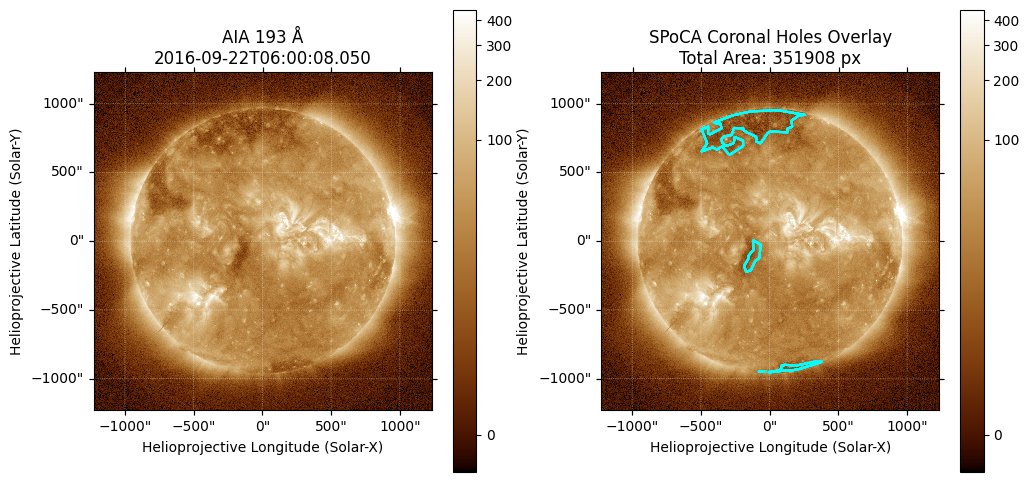

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import TimeDelta
from astropy.coordinates import SkyCoord
from skimage.draw import polygon

import sunpy.map
from sunpy.net import Fido, attrs as a, hek
from sunpy.physics.differential_rotation import solar_rotate_coordinate

# ==========================================
# 1. Fetch Targeted AIA Data
# ==========================================
# Define target time window (1-minute window ensures we catch a frame)
target_start = '2016-09-22T06:00:00'
target_end = '2016-09-22T06:01:00'

print(f"Fetching AIA 193 Å map for {target_start}...")
aia_search = Fido.search(
    a.Time(target_start, target_end),
    a.Instrument.aia,
    a.Wavelength(193 * u.angstrom)
)
# Download the first matching frame
downloaded_files = Fido.fetch(aia_search[0, 0])
aia_map = sunpy.map.Map(downloaded_files[0])

# ==========================================
# 2. Query HEK for SPoCA Polygons
# ==========================================
hek_client = hek.HEKClient()
start_time = aia_map.date - TimeDelta(2 * u.hour)
end_time = aia_map.date + TimeDelta(2 * u.hour)

print(f"Querying HEK for SPoCA polygons near {aia_map.date}...")
responses = hek_client.search(
    a.Time(start_time, end_time),
    a.hek.CH,
    a.hek.FRM.Name == 'SPoCA'
)
print(f"Found {len(responses)} HEK records.")

# ==========================================
# 3. Coordinate Transformation & Rasterization
# ==========================================
binary_mask = np.zeros(aia_map.data.shape, dtype=np.uint8)

for ch_boundary in responses['hpc_boundcc']:
    if not ch_boundary:
        continue

    rotated_boundary = solar_rotate_coordinate(ch_boundary, time=aia_map.date)

    Tx = rotated_boundary.Tx.value
    Ty = rotated_boundary.Ty.value

    if hasattr(Tx, 'filled'):
        Tx = Tx.filled(np.nan)
        Ty = Ty.filled(np.nan)

    valid_mask = ~np.isnan(Tx) & ~np.isnan(Ty)
    if not np.any(valid_mask):
        continue

    clean_boundary = SkyCoord(
        Tx[valid_mask] * rotated_boundary.Tx.unit,
        Ty[valid_mask] * rotated_boundary.Ty.unit,
        frame=rotated_boundary.frame
    )

    px, py = aia_map.wcs.world_to_pixel(clean_boundary)

    rr, cc = polygon(py, px, shape=binary_mask.shape)
    binary_mask[rr, cc] = 1

# ==========================================
# 4. Area Calculation & Visualization
# ==========================================
pixel_count = np.count_nonzero(binary_mask)
pixel_area_arcsec2 = aia_map.scale[0].value * aia_map.scale[1].value
total_area_arcsec2 = pixel_count * pixel_area_arcsec2

print(f"Total Coronal Hole Area: {pixel_count} pixels")
print(f"Approximate Physical Area: {total_area_arcsec2:.2f} arcsec^2")

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection=aia_map)
aia_map.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
ax1.set_title(f"AIA 193 Å\n{aia_map.date}")
plt.colorbar()
ax2 = fig.add_subplot(122, projection=aia_map)
aia_map.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
ax2.contour(binary_mask, colors='cyan', linewidths=1.5)
ax2.set_title(f"SPoCA Coronal Holes Overlay\nTotal Area: {pixel_count} px")
plt.colorbar()
plt.show()

Image dimensions: (4096, 4096)
Telescope info from header: SPoCA


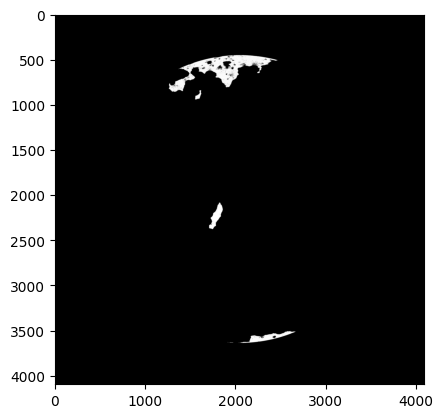

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt

# Open the FITS file
# The 'with' statement ensures the file is closed automatically
with fits.open('20160922_060000.ch_map.fits') as hdu_list:
    # Access the primary data unit (HDU 0 is primary)
    image_data = hdu_list[1].data
    # Access the header information (metadata)
    header = hdu_list[1].header

    print("Image dimensions:", image_data.shape)
    print("Telescope info from header:", header['TELESCOP'])

    # Display the image data using matplotlib
    plt.imshow(image_data[::-1, :], cmap='gray')

Closest Zarr observation found at: 2017-01-21 00:00:04.850000


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,dsun_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs,dsun_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,dsun_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs,dsun_obs




--- Metrics ---
ch_mean: 44.23
ch_median: 37.24
ch_min: 12.39
mean_darkest_25: 22.04
qs_median: 128.12


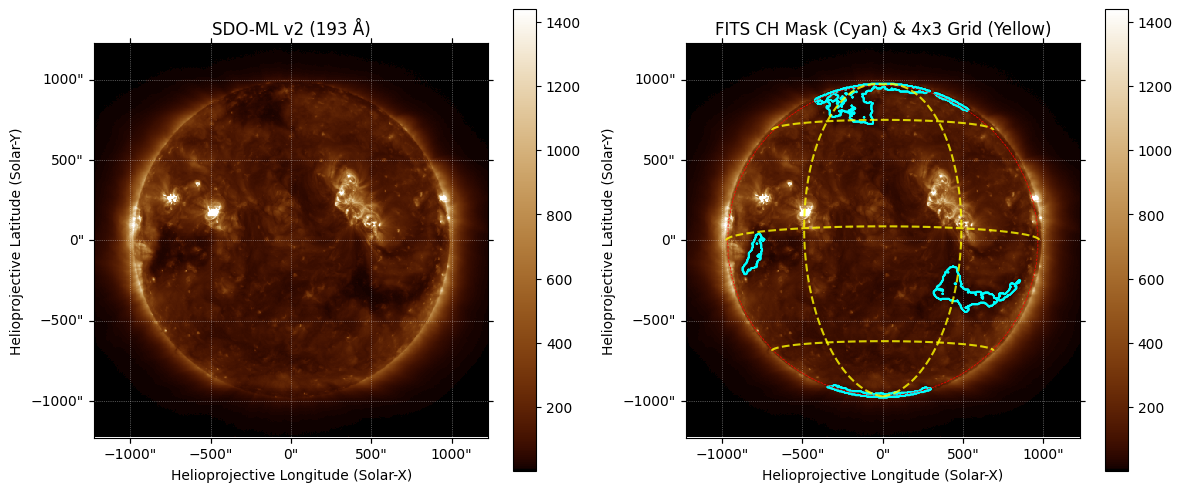


--- CH Metrics per Symmetric Grid Cell (2x3) ---
[Equatorial | ±0° to ±45°] & [Lon -90° to -30°]
  Mean: 34.64 | Median: 33.58 | Min: 22.97 | Darkest 25%: 26.64
[Equatorial | ±0° to ±45°] & [Lon -30° to  30°]
  Mean: 26.56 | Median: 25.68 | Min: 12.39 | Darkest 25%: 17.33
[Equatorial | ±0° to ±45°] & [Lon  30° to  90°]
  Mean: 29.41 | Median: 28.88 | Min: 13.36 | Darkest 25%: 17.90
[Polar | ±45° to ±90°] & [Lon -90° to -30°]
  Mean: 65.12 | Median: 64.30 | Min: 29.79 | Darkest 25%: 44.00
[Polar | ±45° to ±90°] & [Lon -30° to  30°]
  Mean: 45.54 | Median: 40.93 | Min: 18.17 | Darkest 25%: 27.07
[Polar | ±45° to ±90°] & [Lon  30° to  90°]
  Mean: 79.34 | Median: 80.36 | Min: 45.22 | Darkest 25%: 58.77


In [ ]:
from sunpy.coordinates import frames
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
import matplotlib.pyplot as plt

# 1. Setup S3 Connection for 2014
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2017 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2017"
store = s3fs.S3Map(root=AWS_ZARR_2017, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]

# 2. Find closest index to 2016-08-21T00:00:00
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))
target_time = pd.Timestamp('2017-01-21T00:00:00')
idx = np.argmin(np.abs(zarr_times - target_time))
obs_time = zarr_times[idx]
print(f"Closest Zarr observation found at: {obs_time}")

# 3. Create Synthetic SunPy Map from Zarr Metadata
# This is required for the WCS world_to_pixel transformation
header = {
    'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
    'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
    'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
    'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
    'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
    'DATE-OBS': obs_time.isoformat(),
    'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
    'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
}
img_data = data_193[idx]
sdoml_map = sunpy.map.Map(img_data, header)

# 4. Fetch Coronal Hole Mask from FITS
with fits.open('20170121_000000.ch_map.fits') as hdu_list:
    # Access HDU 1 as you specified
    ch_data = hdu_list[1].data
    ch_header = hdu_list[1].header

# Create a SunPy map from the FITS mask
ch_map_full_res = sunpy.map.Map(ch_data, ch_header)

# 5. Resample / Reproject the Mask
# SDO-ML images are typically 512x512. We need the mask to match exactly.
# We reproject the CH mask onto the WCS footprint of the SDO-ML map.
# (If you don't have the 'reproject' package installed, you can use ch_map_full_res.resample(sdoml_map.data.shape * u.pix))

import reproject
ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)

# Create the binary mask array
# We use a threshold (e.g., > 0.5) in case interpolation created fractional values
binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

# 6. Calculate Metrics
# Quiet Sun Median (99% Shrunken Disk)
hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
qs_median = np.nanmedian(img_data[qs_mask])

# Coronal Hole Metrics
ch_pix = img_data[binary_mask.astype(bool)]
ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

if len(ch_pix) > 0:
    metrics = {
        'ch_mean': np.nanmean(ch_pix),
        'ch_median': np.nanmedian(ch_pix),
        'ch_min': np.nanmin(ch_pix),
        'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
        'qs_median': qs_median
    }
else:
    metrics = {k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'qs_median']}

# Add this import at the top of your file if you haven't already
from sunpy.coordinates import frames

# 7. Visualization & Verification
print("\n--- Metrics ---")
for k, v in metrics.items(): print(f"{k}: {v:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': sdoml_map})

# -- AXIS 1: Raw Image --
im1 = sdoml_map.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent, cmap='sdoaia193')
ax1.set_title("SDO-ML v2 (193 Å)")
plt.colorbar(im1, ax=ax1)

# -- AXIS 2: Mask & 4x3 Grid Overlay --
im2 = sdoml_map.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent, cmap='sdoaia193')
ax2.contour(binary_mask, colors='cyan', linewidths=1)
ax2.contour(qs_mask, colors='red', linestyles='dashed', linewidths=0.5)

# --- OVERLAY THE 4x3 GRID ---
# 4 Latitude bands = 3 dividing lines at -45, 0, 45 degrees
lat_lines = [-45, 0, 45] * u.deg
# 3 Longitude bands = 2 dividing lines at -30, 30 degrees
lon_lines = [-30, 30] * u.deg

# Draw Latitude lines
for lat_val in lat_lines:
    lon_arr = np.linspace(-90, 90, 100) * u.deg
    lat_arr = np.full(100, lat_val.value) * u.deg
    line_coords = SkyCoord(lon=lon_arr, lat=lat_arr,
                           frame=frames.HeliographicStonyhurst,
                           obstime=sdoml_map.date)
    ax2.plot_coord(line_coords, color='yellow', linestyle='--', linewidth=1.5, alpha=0.8)

# Draw Longitude lines
for lon_val in lon_lines:
    lat_arr = np.linspace(-90, 90, 100) * u.deg
    lon_arr = np.full(100, lon_val.value) * u.deg
    line_coords = SkyCoord(lon=lon_arr, lat=lat_arr,
                           frame=frames.HeliographicStonyhurst,
                           obstime=sdoml_map.date)
    ax2.plot_coord(line_coords, color='yellow', linestyle='--', linewidth=1.5, alpha=0.8)

ax2.set_title("FITS CH Mask (Cyan) & 4x3 Grid (Yellow)")
plt.colorbar(im2, ax=ax2)

plt.show()
# 1. Get Lat/Lon for every pixel in the map
hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)

# Extract lat/lon in degrees
lat = hgs_coords.lat.to('deg').value
lon = hgs_coords.lon.to('deg').value

# USE ABSOLUTE LATITUDE FOR NORTH/SOUTH SYMMETRY
abs_lat = np.abs(lat)

# 2. Define the 2x3 Symmetric Grid Boundaries
abs_lat_bounds = [0, 45, 90]  # 2 symmetric latitude bands
lon_bounds = [-90, -30, 30, 90] # 3 longitude bands

# Dictionary to store the metrics for the 6 symmetric cells
grid_metrics_sym = {}

print("\n--- CH Metrics per Symmetric Grid Cell (2x3) ---")

# 3. Iterate over the 6 cells
for i in range(2): # Absolute Latitude bounds (Equatorial, then Polar)
    lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]

    for j in range(3): # Longitude bounds
        lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

        # Mask 1: Pixels geometrically inside this symmetric (i,j) cell
        # This automatically grabs BOTH the North and South hemispheres for this latitude band
        in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)

        # Mask 2: Pixels in this cell that are ALSO classified as Coronal Holes
        ch_in_cell = in_cell & binary_mask.astype(bool)

        # Extract the intensity values
        ch_pixels = img_data[ch_in_cell]
        ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

        # Name the region for clarity
        lat_name = "Equatorial" if i == 0 else "Polar"
        cell_name = f"SymCell_{lat_name}_Lon{j}"

        # Compute metrics if the cell contains CH pixels
        if len(ch_pixels) > 0:
            metrics_ij = {
                'ch_mean': np.nanmean(ch_pixels),
                'ch_median': np.nanmedian(ch_pixels),
                'ch_min': np.nanmin(ch_pixels),
                'mean_darkest_25': np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            }
        else:
            # Output NaNs if the cell is empty of coronal holes
            metrics_ij = {k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25']}

        grid_metrics_sym[cell_name] = metrics_ij

        # Print results neatly
        print(f"[{lat_name} | ±{lat_min}° to ±{lat_max}°] & [Lon {lon_min:3d}° to {lon_max:3d}°]")
        if len(ch_pixels) > 0:
            print(f"  Mean: {metrics_ij['ch_mean']:.2f} | Median: {metrics_ij['ch_median']:.2f} | "
                  f"Min: {metrics_ij['ch_min']:.2f} | Darkest 25%: {metrics_ij['mean_darkest_25']:.2f}")
        else:
            print("  No Coronal Hole pixels in this symmetric region.")

Closest Zarr observation found at: 2017-01-20 23:59:57.630000


For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs,dsun_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,crln_obs,dsun_obs




--- Metrics ---
ch_mean: 12.39
ch_median: 10.14
ch_min: 3.52
mean_darkest_25: 6.07
qs_median: 31.48


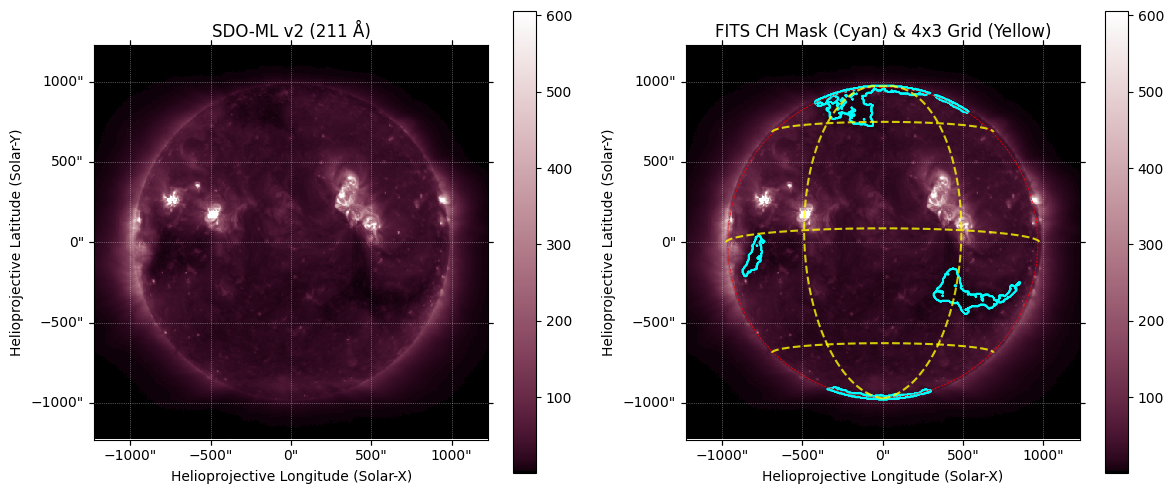


--- CH Metrics per Symmetric Grid Cell (2x3) ---
[Equatorial | ±0° to ±45°] & [Lon -90° to -30°]
  Mean: 9.74 | Median: 9.41 | Min: 5.86 | Darkest 25%: 7.37
[Equatorial | ±0° to ±45°] & [Lon -30° to  30°]
  Mean: 7.03 | Median: 6.82 | Min: 3.53 | Darkest 25%: 4.90
[Equatorial | ±0° to ±45°] & [Lon  30° to  90°]
  Mean: 8.02 | Median: 7.75 | Min: 3.52 | Darkest 25%: 5.04
[Polar | ±45° to ±90°] & [Lon -90° to -30°]
  Mean: 18.77 | Median: 17.08 | Min: 8.15 | Darkest 25%: 12.15
[Polar | ±45° to ±90°] & [Lon -30° to  30°]
  Mean: 12.53 | Median: 11.17 | Min: 4.95 | Darkest 25%: 7.48
[Polar | ±45° to ±90°] & [Lon  30° to  90°]
  Mean: 22.59 | Median: 21.35 | Min: 12.33 | Darkest 25%: 16.42


In [ ]:
from sunpy.coordinates import frames
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.coordinates import SkyCoord
from skimage.draw import polygon
from sunpy.net import hek, attrs as a
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import sunpy.map
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. Setup S3 Connection for 2014
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2017 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2017"
store = s3fs.S3Map(root=AWS_ZARR_2017, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]

# 2. Find closest index to 2016-08-21T00:00:00
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))
target_time = pd.Timestamp('2017-01-21T00:00:00')
idx = np.argmin(np.abs(zarr_times - target_time))
obs_time = zarr_times[idx]
print(f"Closest Zarr observation found at: {obs_time}")

# 3. Create Synthetic SunPy Map from Zarr Metadata
# This is required for the WCS world_to_pixel transformation
header = {
    'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
    'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
    'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
    'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
    'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
    'DATE-OBS': obs_time.isoformat(),
    'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
    'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
}
img_data = data_211[idx]
sdoml_map = sunpy.map.Map(img_data, header)

# 4. Fetch Coronal Hole Mask from FITS
with fits.open('20170121_000000.ch_map.fits') as hdu_list:
    # Access HDU 1 as you specified
    ch_data = hdu_list[1].data
    ch_header = hdu_list[1].header

# Create a SunPy map from the FITS mask
ch_map_full_res = sunpy.map.Map(ch_data, ch_header)

# 5. Resample / Reproject the Mask
# SDO-ML images are typically 512x512. We need the mask to match exactly.
# We reproject the CH mask onto the WCS footprint of the SDO-ML map.
# (If you don't have the 'reproject' package installed, you can use ch_map_full_res.resample(sdoml_map.data.shape * u.pix))

import reproject
ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)

# Create the binary mask array
# We use a threshold (e.g., > 0.5) in case interpolation created fractional values
binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

# 6. Calculate Metrics
# Quiet Sun Median (99% Shrunken Disk)
hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
qs_median = np.nanmedian(img_data[qs_mask])

# Coronal Hole Metrics
ch_pix = img_data[binary_mask.astype(bool)]
ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

if len(ch_pix) > 0:
    metrics = {
        'ch_mean': np.nanmean(ch_pix),
        'ch_median': np.nanmedian(ch_pix),
        'ch_min': np.nanmin(ch_pix),
        'mean_darkest_25': np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)]),
        'qs_median': qs_median
    }
else:
    metrics = {k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25', 'qs_median']}

# Add this import at the top of your file if you haven't already
from sunpy.coordinates import frames

# 7. Visualization & Verification
print("\n--- Metrics ---")
for k, v in metrics.items(): print(f"{k}: {v:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': sdoml_map})

# -- AXIS 1: Raw Image --
im1 = sdoml_map.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent, cmap='sdoaia211')
ax1.set_title("SDO-ML v2 (211 Å)")
plt.colorbar(im1, ax=ax1)

# -- AXIS 2: Mask & 4x3 Grid Overlay --
im2 = sdoml_map.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent, cmap='sdoaia211')
ax2.contour(binary_mask, colors='cyan', linewidths=1)
ax2.contour(qs_mask, colors='red', linestyles='dashed', linewidths=0.5)

# --- OVERLAY THE 4x3 GRID ---
# 4 Latitude bands = 3 dividing lines at -45, 0, 45 degrees
lat_lines = [-45, 0, 45] * u.deg
# 3 Longitude bands = 2 dividing lines at -30, 30 degrees
lon_lines = [-30, 30] * u.deg

# Draw Latitude lines
for lat_val in lat_lines:
    lon_arr = np.linspace(-90, 90, 100) * u.deg
    lat_arr = np.full(100, lat_val.value) * u.deg
    line_coords = SkyCoord(lon=lon_arr, lat=lat_arr,
                           frame=frames.HeliographicStonyhurst,
                           obstime=sdoml_map.date)
    ax2.plot_coord(line_coords, color='yellow', linestyle='--', linewidth=1.5, alpha=0.8)

# Draw Longitude lines
for lon_val in lon_lines:
    lat_arr = np.linspace(-90, 90, 100) * u.deg
    lon_arr = np.full(100, lon_val.value) * u.deg
    line_coords = SkyCoord(lon=lon_arr, lat=lat_arr,
                           frame=frames.HeliographicStonyhurst,
                           obstime=sdoml_map.date)
    ax2.plot_coord(line_coords, color='yellow', linestyle='--', linewidth=1.5, alpha=0.8)

ax2.set_title("FITS CH Mask (Cyan) & 4x3 Grid (Yellow)")
plt.colorbar(im2, ax=ax2)

plt.show()
# 1. Get Lat/Lon for every pixel in the map
hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)

# Extract lat/lon in degrees
lat = hgs_coords.lat.to('deg').value
lon = hgs_coords.lon.to('deg').value

# USE ABSOLUTE LATITUDE FOR NORTH/SOUTH SYMMETRY
abs_lat = np.abs(lat)

# 2. Define the 2x3 Symmetric Grid Boundaries
abs_lat_bounds = [0, 45, 90]  # 2 symmetric latitude bands
lon_bounds = [-90, -30, 30, 90] # 3 longitude bands

# Dictionary to store the metrics for the 6 symmetric cells
grid_metrics_sym = {}

print("\n--- CH Metrics per Symmetric Grid Cell (2x3) ---")

# 3. Iterate over the 6 cells
for i in range(2): # Absolute Latitude bounds (Equatorial, then Polar)
    lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]

    for j in range(3): # Longitude bounds
        lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

        # Mask 1: Pixels geometrically inside this symmetric (i,j) cell
        # This automatically grabs BOTH the North and South hemispheres for this latitude band
        in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)

        # Mask 2: Pixels in this cell that are ALSO classified as Coronal Holes
        ch_in_cell = in_cell & binary_mask.astype(bool)

        # Extract the intensity values
        ch_pixels = img_data[ch_in_cell]
        ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

        # Name the region for clarity
        lat_name = "Equatorial" if i == 0 else "Polar"
        cell_name = f"SymCell_{lat_name}_Lon{j}"

        # Compute metrics if the cell contains CH pixels
        if len(ch_pixels) > 0:
            metrics_ij = {
                'ch_mean': np.nanmean(ch_pixels),
                'ch_median': np.nanmedian(ch_pixels),
                'ch_min': np.nanmin(ch_pixels),
                'mean_darkest_25': np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            }
        else:
            # Output NaNs if the cell is empty of coronal holes
            metrics_ij = {k: np.nan for k in ['ch_mean', 'ch_median', 'ch_min', 'mean_darkest_25']}

        grid_metrics_sym[cell_name] = metrics_ij

        # Print results neatly
        print(f"[{lat_name} | ±{lat_min}° to ±{lat_max}°] & [Lon {lon_min:3d}° to {lon_max:3d}°]")
        if len(ch_pixels) > 0:
            print(f"  Mean: {metrics_ij['ch_mean']:.2f} | Median: {metrics_ij['ch_median']:.2f} | "
                  f"Min: {metrics_ij['ch_min']:.2f} | Darkest 25%: {metrics_ij['mean_darkest_25']:.2f}")
        else:
            print("  No Coronal Hole pixels in this symmetric region.")

In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2015 Zarr Data
print("Connecting to SDO-ML 2015 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2015 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2015"
store = s3fs.S3Map(root=AWS_ZARR_2015, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2015
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2015-01-01 00:00:00', end='2015-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2015"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2015/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2015_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2015_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2015 Zarr...
Starting processing of 1460 instances...


Processing 2015:   9%|▉         | 137/1460 [05:38<55:21,  2.51s/it]

Processing 2015:  13%|█▎        | 189/1460 [07:39<52:52,  2.50s/it]

Processing 2015:  17%|█▋        | 245/1460 [09:51<49:57,  2.47s/it]

Processing 2015:  18%|█▊        | 265/1460 [10:13<42:19,  2.13s/it]

...

Failed to process https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/20151121_000000.ch_map.fits: HTTPSConnectionPool(host='spoca.oma.be', port=443): Read timed out. (read timeout=15)


Processing 2015:  99%|█████████▉| 1444/1460 [58:29<00:28,  1.81s/it]

Processing 2015: 100%|██████████| 1460/1460 [59:08<00:00,  2.43s/it]

Processing complete! File saved as 'ch_metrics_2015_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2015-01-01 00:00:00,178.545227,36.655701,33.125580,17.853580,24.650696,33.746819,32.845192,24.358059,27.166016,...,21.110888,26.788416,34.391182,31.313187,19.357258,24.226530,43.517780,40.830292,22.486122,28.609123
1,2015-01-01 06:00:00,178.706085,35.650318,32.414711,18.042475,23.985647,36.347912,36.402267,25.145975,28.704695,...,20.922655,27.004889,32.687412,29.624432,18.640919,23.161022,43.488796,40.741726,22.345160,29.353199
2,2015-01-01 12:00:00,177.165817,35.913887,32.064865,17.590498,23.534327,NaN,NaN,NaN,NaN,...,20.371374,27.631168,32.162365,29.024864,17.590498,22.471142,43.879425,40.788403,21.536760,28.325974
3,2015-01-01 18:00:00,178.862289,35.910664,32.009460,16.568687,23.162302,NaN,NaN,NaN,NaN,...,23.222364,29.529198,31.945953,28.659849,16.568687,21.982979,44.183979,40.030052,20.744583,28.482367
4,2015-01-02 00:00:00,177.876450,35.662724,31.649035,16.815453,22.839806,NaN,NaN,NaN,NaN,...,26.466278,32.925148,31.623552,27.699991,16.815453,21.798365,43.840820,39.829857,21.752258,29.636061


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2016 Zarr Data
print("Connecting to SDO-ML 2016 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2016 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2016"
store = s3fs.S3Map(root=AWS_ZARR_2016, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2016
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2016-01-01 00:00:00', end='2016-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2016"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2016/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2016_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2016_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2016 Zarr...
Starting processing of 1464 instances...


Processing 2016:   3%|▎         | 51/1464 [02:04<55:46,  2.37s/it]

Processing 2016:  42%|████▏     | 609/1464 [25:31<35:10,  2.47s/it]

Processing 2016:  51%|█████▏    | 751/1464 [32:24<42:21,  3.56s/it]

Processing 2016:  59%|█████▊    | 859/1464 [38:00<27:41,  2.75s/it]

...

Processing 2016:  86%|████████▌ | 1253/1464 [53:16<08:48,  2.50s/it]

Processing 2016:  89%|████████▉ | 1301/1464 [55:11<07:06,  2.62s/it]

Processing 2016: 100%|██████████| 1464/1464 [1:01:52<00:00,  2.54s/it]

Processing complete! File saved as 'ch_metrics_2016_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2016-01-01 00:00:00,101.483803,46.679630,36.345901,13.630983,23.256615,37.799145,30.978298,13.630983,20.710552,...,24.738539,34.609818,49.550156,41.915821,14.557109,27.939663,72.928925,66.641243,19.030119,35.947643
1,2016-01-01 06:00:00,100.655769,48.195919,37.125183,13.442446,22.974262,37.616352,30.219496,13.442446,20.430519,...,24.744820,39.115051,52.575672,43.922375,15.954841,30.140799,74.681252,65.734718,22.222704,36.516102
2,2016-01-01 12:00:00,100.965599,49.029255,37.156464,13.498654,22.704180,36.082905,28.760763,13.636209,20.348188,...,24.681839,38.679901,52.901340,44.523426,15.417043,30.814407,74.491562,63.873177,25.308846,37.608360
3,2016-01-01 18:00:00,101.927513,49.552746,37.209351,13.212717,22.495499,37.720997,28.788172,15.081386,22.222013,...,23.605581,40.027130,53.703232,44.730659,18.308441,30.951607,75.383224,61.865818,28.312687,39.806717
4,2016-01-02 00:00:00,102.207993,48.782482,36.829849,12.837437,22.323244,42.630878,30.404995,17.896845,22.448727,...,24.303650,41.619659,52.233997,43.304989,19.645742,31.348368,71.594017,59.920914,27.733351,38.028801


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2017 Zarr Data
print("Connecting to SDO-ML 2017 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2017 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2017"
store = s3fs.S3Map(root=AWS_ZARR_2017, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2017
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2017-01-01 00:00:00', end='2017-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2017"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2017/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2017_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2017_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2017 Zarr...
Starting processing of 1460 instances...


Processing 2017:   7%|▋         | 99/1460 [04:04<55:56,  2.47s/it]

Processing 2017:  28%|██▊       | 407/1460 [16:45<44:09,  2.52s/it]

Processing 2017:  53%|█████▎    | 771/1460 [31:48<31:57,  2.78s/it]

Processing 2017:  55%|█████▍    | 799/1460 [32:58<27:59,  2.54s/it]

...

Processing 2017:  81%|████████  | 1183/1460 [49:26<11:46,  2.55s/it]

Processing 2017:  85%|████████▌ | 1244/1460 [51:58<06:55,  1.93s/it]

Processing 2017: 100%|██████████| 1460/1460 [1:01:06<00:00,  2.51s/it]

Processing complete! File saved as 'ch_metrics_2017_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2017-01-01 00:00:00,113.271523,34.177654,30.250134,11.037005,19.957905,27.766537,25.606316,13.213374,18.346817,...,17.427319,26.420553,33.397953,30.689739,13.257754,20.566477,55.411469,53.912868,18.615259,32.166084
1,2017-01-01 06:00:00,113.692474,33.471375,29.506428,9.691663,19.420835,26.145294,24.279106,13.639942,16.944004,...,15.425453,26.688540,34.230331,31.216095,14.352044,21.383608,54.833130,52.304298,20.243122,31.019695
2,2017-01-01 12:00:00,114.201630,32.737156,28.982086,9.825020,18.948450,26.076454,24.084496,12.858112,16.277346,...,15.934992,26.214304,34.202545,31.527872,15.133043,20.951494,55.009686,55.632626,18.775747,30.690672
3,2017-01-01 18:00:00,114.956085,32.113049,28.573042,11.569818,18.990957,27.248930,24.899944,12.437120,16.719055,...,14.948665,24.365633,34.715805,32.063545,13.541223,21.239435,52.256916,50.812828,19.751074,29.043186
4,2017-01-02 00:00:00,114.785744,31.163702,27.865925,10.968510,18.457909,26.848026,24.872957,15.620992,18.975044,...,16.420189,23.715937,33.964130,31.311563,14.593310,20.977165,48.631260,44.443481,20.009907,27.514296


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2018 Zarr Data
print("Connecting to SDO-ML 2018 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2018 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
store = s3fs.S3Map(root=AWS_ZARR_2018, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2018
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2018-01-01 00:00:00', end='2018-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2018"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2018/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2018_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2018_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2018 Zarr...
Starting processing of 1460 instances...


Processing 2018:   6%|▋         | 92/1460 [03:53<58:57,  2.59s/it]

Processing 2018:  30%|██▉       | 431/1460 [18:14<44:12,  2.58s/it]

Processing 2018:  49%|████▉     | 713/1460 [30:05<27:05,  2.18s/it]

Processing 2018:  53%|█████▎    | 767/1460 [32:16<31:08,  2.70s/it]

Processing 2018:  76%|███████▌  | 1103/1460 [46:35<15:20,  2.58s/it]

Processing 2018:  88%|████████▊ | 1281/1460 [54:09<07:20,  2.46s/it]

Processing 2018: 100%|██████████| 1460/1460 [1:01:37<00:00,  2.53s/it]

Processing complete! File saved as 'ch_metrics_2018_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2018-01-01 00:00:00,100.391426,35.425488,32.993423,13.518563,22.219744,69.903168,68.041397,53.163826,61.409737,...,15.404252,21.408894,32.623886,31.739479,13.518563,21.181091,40.438976,37.748928,16.322573,25.491449
1,2018-01-01 06:00:00,99.641670,36.638084,34.014912,13.468150,22.644606,59.674419,56.996750,46.471836,50.223270,...,14.692685,23.246523,32.597591,31.510738,13.468150,21.184822,42.879585,40.092903,17.050335,25.676895
2,2018-01-01 12:00:00,100.114807,36.307251,33.774235,13.115188,22.278124,50.506397,47.535679,36.644760,40.310730,...,16.475908,25.587788,31.939692,30.699574,13.115188,20.406948,41.547283,38.868763,16.725988,24.513466
3,2018-01-01 18:00:00,100.427086,35.194675,33.394470,12.652288,21.817495,42.724171,41.180470,31.342562,35.481007,...,15.360849,26.251326,30.567089,28.989319,12.652288,19.788040,40.893463,38.340656,17.926996,24.560804
4,2018-01-02 00:00:00,100.444984,34.846783,33.194057,12.832954,21.444851,37.738911,36.303806,27.898451,31.750921,...,16.545994,26.872992,30.071720,28.186970,12.832954,19.271723,39.570190,37.169456,18.293970,25.217161


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2019 Zarr Data
print("Connecting to SDO-ML 2019 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2019 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2019"
store = s3fs.S3Map(root=AWS_ZARR_2019, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2019
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2019-01-01 00:00:00', end='2019-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2019"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2019/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2019_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2019_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2019 Zarr...
Starting processing of 1460 instances...


Processing 2019:  18%|█▊        | 260/1460 [10:54<50:35,  2.53s/it]

Processing 2019:  40%|███▉      | 581/1460 [24:00<33:56,  2.32s/it]

Processing 2019:  43%|████▎     | 634/1460 [26:19<1:30:05,  6.54s/it]

Failed to process https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/20190608_060000.ch_map.fits: HTTPSConnectionPool(host='spoca.oma.be', port=443): Read timed out. (read timeout=15)


...

Processing 2019:  78%|███████▊  | 1141/1460 [47:43<13:21,  2.51s/it]

Processing 2019:  83%|████████▎ | 1211/1460 [50:33<10:27,  2.52s/it]

Processing 2019: 100%|██████████| 1460/1460 [1:00:56<00:00,  2.50s/it]

Processing complete! File saved as 'ch_metrics_2019_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2019-01-01 00:00:00,109.132301,39.086880,33.627201,10.077251,20.869404,31.065052,30.293621,17.779535,23.942381,...,30.935364,42.540932,62.145718,62.495167,34.279266,48.248890,55.228714,54.372707,25.694109,36.620476
1,2019-01-01 06:00:00,107.799248,38.872173,33.146023,10.691935,20.423700,28.587639,28.137781,14.604193,19.705326,...,33.217030,43.426292,60.365665,60.517120,30.155706,44.297581,60.439846,59.990921,32.076645,43.164215
2,2019-01-01 12:00:00,109.515640,38.853600,32.836975,12.028567,21.068207,30.932364,30.280689,17.281488,24.318016,...,31.705770,43.807804,61.850010,62.075035,29.253363,43.109383,63.234241,62.637604,39.423439,48.378185
3,2019-01-01 18:00:00,108.076324,39.042938,32.248215,12.981136,20.424633,32.512020,31.940588,24.964128,28.095201,...,35.664631,41.842808,65.778122,66.057930,35.206997,46.670624,69.916313,68.370514,39.912586,54.850815
4,2019-01-02 00:00:00,107.426277,39.802433,32.808277,12.011015,21.366388,31.029072,30.535210,21.617331,24.184179,...,32.895447,39.880775,65.170311,63.959717,35.588562,48.244953,73.952438,73.167564,44.257774,58.855499


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2010 Zarr Data
print("Connecting to SDO-ML 2010 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2010 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
store = s3fs.S3Map(root=AWS_ZARR_2010, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2010
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2010-01-01 00:00:00', end='2010-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2010"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2010/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2010_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2010_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2010 Zarr...
Starting processing of 1460 instances...


Processing 2010:   2%|▏         | 22/1460 [00:00<00:06, 218.42it/s]

Processing 2010:   8%|▊         | 110/1460 [00:00<00:02, 601.57it/s]

Processing 2010:  13%|█▎        | 189/1460 [00:00<00:01, 686.47it/s]

Processing 2010:  19%|█▊        | 273/1460 [00:00<00:01, 742.35it/s]

...

Processing 2010:  95%|█████████▍| 1386/1460 [31:19<03:04,  2.49s/it]

Processing 2010: 100%|█████████▉| 1453/1460 [33:50<00:16,  2.42s/it]

Processing 2010: 100%|██████████| 1460/1460 [34:00<00:00,  1.40s/it]

Processing complete! File saved as 'ch_metrics_2010_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2010-05-13 00:00:00,105.332748,39.282795,35.159447,12.640677,23.514193,39.281166,36.107666,18.199156,25.032593,...,36.255905,60.162712,47.669128,44.611221,22.804859,34.203293,46.304230,42.261116,21.395800,31.052670
1,2010-05-13 06:00:00,106.297699,39.192616,34.823112,15.576619,23.759724,38.139313,34.971241,16.521877,23.838324,...,43.605522,53.041252,47.560452,46.974319,23.547832,33.044708,46.905422,43.116058,25.239792,31.759237
2,2010-05-13 12:00:00,104.217941,38.763924,35.120770,13.852631,22.496157,36.270908,32.788181,13.852631,21.348858,...,33.092293,40.900063,48.628654,47.117790,26.600124,36.346165,48.831005,45.594131,26.209818,33.047047
3,2010-05-13 18:00:00,102.118561,38.410225,34.641903,11.694215,21.129726,33.328671,29.809322,11.694215,18.274443,...,25.057943,36.633404,47.694504,46.216053,27.273565,33.498173,52.644157,50.265533,27.691828,36.456158
4,2010-05-14 00:00:00,100.828880,39.390110,34.721298,11.540844,19.496977,31.422911,26.915621,11.540844,16.888897,...,26.296995,35.234928,48.968285,47.205887,26.445490,33.944828,55.436935,53.096458,28.637314,37.186825


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2011 Zarr Data
print("Connecting to SDO-ML 2011 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2011 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2011"
store = s3fs.S3Map(root=AWS_ZARR_2011, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2011
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2011-01-01 00:00:00', end='2011-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2011"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2011/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2011_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2011_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2011 Zarr...
Starting processing of 1460 instances...


Processing 2011:   5%|▍         | 69/1460 [02:50<57:48,  2.49s/it]

Processing 2011:   7%|▋         | 107/1460 [04:18<56:35,  2.51s/it]

Processing 2011:   9%|▉         | 133/1460 [05:22<55:38,  2.52s/it]

Processing 2011:  10%|█         | 149/1460 [05:56<56:43,  2.60s/it]

...

Processing 2011:  94%|█████████▍| 1377/1460 [52:05<03:22,  2.44s/it]

Processing 2011:  95%|█████████▍| 1381/1460 [52:12<02:44,  2.09s/it]

Processing 2011: 100%|██████████| 1460/1460 [55:01<00:00,  2.26s/it]

Processing complete! File saved as 'ch_metrics_2011_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2011-01-01 00:00:00,107.314812,45.835148,38.966801,14.130282,23.167789,37.001816,33.274475,16.092991,21.661015,...,19.444630,36.032265,41.000526,36.343628,14.130282,21.214865,63.371975,60.831024,20.771280,35.617760
1,2011-01-01 06:00:00,107.707245,46.176285,39.008114,12.988266,23.194157,34.225864,32.281677,15.317798,20.277813,...,18.245287,33.702518,42.844910,37.201546,12.988266,21.865425,69.114616,67.409943,22.823902,36.677570
2,2011-01-01 12:00:00,108.580177,45.175381,36.867821,13.893334,22.656710,32.222630,31.247906,14.629567,20.237270,...,19.243343,30.922262,42.851116,36.215523,13.893334,21.640491,71.871895,72.293678,24.471634,37.091728
3,2011-01-01 18:00:00,109.723495,49.480751,39.433792,13.089602,23.071548,33.246964,32.657555,14.226242,20.756748,...,19.734333,30.901997,43.711372,35.929405,13.089602,21.778597,79.159981,81.404243,23.051027,47.389400
4,2011-01-02 00:00:00,110.987640,45.973595,36.869396,13.161605,22.433378,32.908657,32.595295,16.276186,23.940104,...,22.337454,30.336428,42.192627,34.524220,13.497656,21.740852,71.512581,73.413231,21.943470,39.939713


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar

# 1. Setup S3 Connection for 2012 Zarr Data
print("Connecting to SDO-ML 2012 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2012 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2012"
store = s3fs.S3Map(root=AWS_ZARR_2012, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2012
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2012-01-01 00:00:00', end='2012-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2012"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2012/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2012_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2012_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2012 Zarr...
Starting processing of 1464 instances...


Processing 2012:   6%|▋         | 93/1464 [03:50<1:00:09,  2.63s/it]

Processing 2012:   7%|▋         | 109/1464 [04:23<55:17,  2.45s/it]

Processing 2012:  17%|█▋        | 245/1464 [09:54<50:14,  2.47s/it]

Processing 2012:  18%|█▊        | 257/1464 [10:17<48:08,  2.39s/it]

...

Processing 2012:  97%|█████████▋| 1421/1464 [53:07<01:45,  2.46s/it]

Processing 2012:  98%|█████████▊| 1429/1464 [53:19<01:12,  2.06s/it]

Processing 2012: 100%|██████████| 1464/1464 [54:32<00:00,  2.23s/it]

Processing complete! File saved as 'ch_metrics_2012_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2012-01-01 00:00:00,196.225952,40.097221,36.546509,20.738398,27.966759,NaN,NaN,NaN,NaN,...,43.541931,47.750809,38.455379,35.792698,21.546040,28.247017,40.340767,37.641056,20.738398,27.556253
1,2012-01-01 06:00:00,197.837265,39.981983,36.589455,21.838314,28.724533,NaN,NaN,NaN,NaN,...,50.358410,53.134884,38.927689,35.971203,24.872669,29.128374,39.904606,37.883945,21.838314,28.324495
2,2012-01-01 12:00:00,200.136673,39.657242,36.826874,23.892879,29.165586,NaN,NaN,NaN,NaN,...,52.255726,55.010311,37.283440,35.369583,23.892879,27.907524,41.120148,38.547955,24.889780,29.992727
3,2012-01-01 18:00:00,206.744339,40.255539,38.448387,23.510685,29.899527,NaN,NaN,NaN,NaN,...,53.977989,55.742001,37.113293,35.108044,23.510685,27.809681,42.033558,40.590065,25.720745,31.557201
4,2012-01-02 00:00:00,205.132065,39.683357,38.452370,22.756470,29.141220,NaN,NaN,NaN,NaN,...,NaN,NaN,34.259087,31.972519,22.756470,26.496050,42.534729,41.107224,26.687639,33.410828


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2013 Zarr Data
print("Connecting to SDO-ML 2013 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2013 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2013"
store = s3fs.S3Map(root=AWS_ZARR_2013, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2013
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2013-01-01 00:00:00', end='2013-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2013"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2013/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2013_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2013_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2013 Zarr...


/tmp/ipykernel_3942/1084299023.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2013-01-01 00:00:00', end='2013-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2013:   7%|▋         | 109/1460 [04:37<57:39,  2.56s/it]

Processing 2013:   9%|▉         | 129/1460 [05:19<56:00,  2.52s/it]

...

Processing 2013:  64%|██████▎   | 930/1460 [42:24<24:24,  2.76s/it]

Processing 2013:  81%|████████▏ | 1189/1460 [53:09<09:40,  2.14s/it]

Processing 2013: 100%|██████████| 1460/1460 [1:04:40<00:00,  2.66s/it]

Processing complete! File saved as 'ch_metrics_2013_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2013-01-01 00:00:00,174.106415,60.605762,57.225811,43.483250,48.218521,NaN,NaN,NaN,NaN,...,43.483250,47.933296,55.912655,52.566868,46.141663,49.362713,NaN,NaN,NaN,NaN
1,2013-01-01 06:00:00,173.894455,63.176392,61.187862,46.261368,50.675957,NaN,NaN,NaN,NaN,...,46.261368,50.019161,60.220684,59.283619,51.410305,53.138229,NaN,NaN,NaN,NaN
2,2013-01-01 12:00:00,175.558899,68.653862,66.369072,51.120449,56.604881,NaN,NaN,NaN,NaN,...,51.120449,55.570534,65.507660,64.669731,58.422115,60.036919,NaN,NaN,NaN,NaN
3,2013-01-01 18:00:00,177.807983,70.485512,69.249382,45.773941,56.847534,51.849541,50.838120,45.773941,47.747253,...,58.962795,62.808384,72.693207,71.385704,59.464939,62.912571,NaN,NaN,NaN,NaN
4,2013-01-02 00:00:00,179.841125,71.020287,70.702698,42.303154,49.018303,67.992989,52.923653,42.303154,43.574783,...,53.254486,64.921387,61.923492,60.249939,50.009235,52.811962,NaN,NaN,NaN,NaN


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2014 Zarr Data
print("Connecting to SDO-ML 2014 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2014 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2014"
store = s3fs.S3Map(root=AWS_ZARR_2014, s3=s3)
root = zarr.open(store=store, mode="r")
data_193 = root["193A"]
zarr_times = pd.to_datetime(list(data_193.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2014
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2014-01-01 00:00:00', end='2014-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2014"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_193.attrs['CDELT1'][idx], 'CDELT2': data_193.attrs['CDELT2'][idx],
        'CRPIX1': data_193.attrs['CRPIX1'][idx], 'CRPIX2': data_193.attrs['CRPIX2'][idx],
        'CRVAL1': data_193.attrs['CRVAL1'][idx], 'CRVAL2': data_193.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_193.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_193.shape[2], 'NAXIS2': data_193.shape[1]
    }
    img_data = data_193[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2014/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_metrics_2014_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_metrics_2014_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2014 Zarr...


/tmp/ipykernel_3942/3138310746.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2014-01-01 00:00:00', end='2014-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2014:  12%|█▏        | 169/1460 [07:21<57:55,  2.69s/it]

Processing 2014:  13%|█▎        | 189/1460 [08:06<54:48,  2.59s/it]

...

Processing 2014:  97%|█████████▋| 1421/1460 [55:10<01:40,  2.58s/it]

Processing 2014:  99%|█████████▉| 1445/1460 [56:04<00:39,  2.62s/it]

Processing 2014: 100%|██████████| 1460/1460 [56:38<00:00,  2.33s/it]

Processing complete! File saved as 'ch_metrics_2014_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2014-01-01 00:00:00,175.925751,30.204374,29.718164,17.148191,23.169821,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-01-01 06:00:00,178.879639,31.187252,30.647041,18.884575,24.199257,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-01-01 12:00:00,181.979614,31.257750,30.975430,18.427290,24.554714,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-01-01 18:00:00,180.010544,31.697796,31.231556,19.877157,24.989292,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-01-02 00:00:00,181.206619,31.671888,31.201496,21.301437,25.834990,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import os

# List to hold the dataframes for each year
all_years_data = []

print("Looking for yearly CSV files...")

# Loop through years 2010 to 2019
for year in range(2010, 2020):
    filename = f"ch_metrics_{year}_6h_cadence.csv"

    # Check if the file exists in your Colab environment
    if os.path.exists(filename):
        print(f"Loading {filename}...")
        df_year = pd.read_csv(filename)
        all_years_data.append(df_year)
    else:
        print(f"File NOT found: {filename} (Skipping)")

# If we found at least one file, combine them
if len(all_years_data) > 0:
    print("\nConcatenating data...")
    # Combine all into one DataFrame
    master_df = pd.concat(all_years_data, ignore_index=True)

    # Convert 'timestamp' to actual datetime objects and sort chronologically
    master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])
    master_df = master_df.sort_values('timestamp').reset_index(drop=True)

    # Save the combined dataset
    output_filename = "ch_metrics_2010_to_2019_master.csv"
    master_df.to_csv(output_filename, index=False)

    print(f"Success! Combined {len(all_years_data)} files into '{output_filename}'.")
    print(f"Total rows: {len(master_df)}")

    # Show the first few rows and the date range
    print(f"Date range: {master_df['timestamp'].min()} to {master_df['timestamp'].max()}")
else:
    print("\nNo CSV files were found to combine. Make sure they are in the current working directory.")

Looking for yearly CSV files...
Loading ch_metrics_2010_6h_cadence.csv...
Loading ch_metrics_2011_6h_cadence.csv...
Loading ch_metrics_2012_6h_cadence.csv...
Loading ch_metrics_2013_6h_cadence.csv...
Loading ch_metrics_2014_6h_cadence.csv...
Loading ch_metrics_2015_6h_cadence.csv...
Loading ch_metrics_2016_6h_cadence.csv...
Loading ch_metrics_2017_6h_cadence.csv...
Loading ch_metrics_2018_6h_cadence.csv...
Loading ch_metrics_2019_6h_cadence.csv...

Concatenating data...
Success! Combined 10 files into 'ch_metrics_2010_to_2019_master.csv'.
Total rows: 13226
Date range: 2010-05-13 00:00:00 to 2019-12-31 18:00:00


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2010 Zarr Data
print("Connecting to SDO-ML 2010 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2010 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2010"
store = s3fs.S3Map(root=AWS_ZARR_2010, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2010
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2010-01-01 00:00:00', end='2010-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2010"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2010/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2010_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2010_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2010 Zarr...


/tmp/ipykernel_53907/3770336047.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2010-01-01 00:00:00', end='2010-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2010:   7%|▋         | 96/1460 [00:00<00:01, 959.31it/s]

Processing 2010:  13%|█▎        | 192/1460 [00:00<00:01, 928.80it/s]

...

Processing 2010:  95%|█████████▍| 1386/1460 [34:54<03:33,  2.89s/it]

Processing 2010: 100%|█████████▉| 1453/1460 [37:43<00:18,  2.71s/it]

Processing 2010: 100%|██████████| 1460/1460 [37:54<00:00,  1.56s/it]

Processing complete! File saved as 'ch_211_2010_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2010-05-13 00:00:00,25.446117,11.368820,10.115082,3.817731,6.898294,11.878570,11.020690,5.193826,7.762270,...,11.166565,15.816952,13.843589,13.171618,6.583212,10.241776,13.870721,12.854159,5.954288,9.554172
1,2010-05-13 06:00:00,25.326355,11.329722,10.169948,4.607417,7.016754,11.390613,10.402260,4.766683,7.340017,...,12.580026,14.221697,13.494985,13.403461,7.220321,9.994481,13.934486,12.995535,6.911675,9.832422
2,2010-05-13 12:00:00,24.881088,11.145763,10.141821,3.675785,6.719167,10.722505,9.747217,3.675785,6.599250,...,9.073832,11.593511,13.662130,13.112617,7.652918,10.686315,14.412050,13.606166,7.254018,10.212216
3,2010-05-13 18:00:00,24.085676,10.977528,9.859917,3.424008,6.324762,9.843892,8.908166,3.424008,5.676558,...,7.429983,10.827112,13.446413,12.989015,8.088104,10.032112,15.201950,14.350311,8.448088,10.900406
4,2010-05-14 00:00:00,23.675890,11.299644,10.173584,3.389535,5.927373,9.284358,8.201199,3.389535,5.236305,...,7.518054,10.545486,13.997726,13.281118,8.361160,10.181041,15.859202,14.829158,8.788160,11.138984


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2011 Zarr Data
print("Connecting to SDO-ML 2011 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2011 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2011"
store = s3fs.S3Map(root=AWS_ZARR_2011, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2011
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2011-01-01 00:00:00', end='2011-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2011"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2011/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2011_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2011_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2011 Zarr...


/tmp/ipykernel_14699/1401841175.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2011-01-01 00:00:00', end='2011-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2011:   5%|▍         | 69/1460 [02:26<51:21,  2.22s/it]

Processing 2011:   7%|▋         | 107/1460 [03:41<50:04,  2.22s/it]

...

Processing 2011:  94%|█████████▍| 1377/1460 [44:16<02:58,  2.16s/it]

Processing 2011:  95%|█████████▍| 1381/1460 [44:23<02:24,  1.83s/it]

Processing 2011: 100%|██████████| 1460/1460 [46:55<00:00,  1.93s/it]

Processing complete! File saved as 'ch_211_2011_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2011-01-01 00:00:00,24.745924,12.978846,11.670008,4.495259,7.422388,11.474466,10.390089,5.014339,7.093851,...,6.257488,10.975574,11.762820,10.814352,4.495259,6.992813,16.666082,15.767101,6.341030,11.036047
1,2011-01-01 06:00:00,24.701542,12.921002,11.524674,4.023762,7.397042,10.581028,10.030962,4.678141,6.678884,...,6.160025,10.217518,12.166012,11.018974,4.023762,7.108143,17.457438,16.733490,6.579930,10.663929
2,2011-01-01 12:00:00,25.134712,12.682591,11.077288,4.444068,7.250770,10.090753,9.648582,4.659986,6.899548,...,6.565975,9.445762,12.186598,10.850833,4.444068,7.069065,18.067987,17.831383,7.066754,10.860222
3,2011-01-01 18:00:00,25.719790,13.623567,11.722147,4.153042,7.321143,10.120054,9.754984,4.725828,6.923856,...,6.287068,9.571834,12.483629,10.839768,4.153042,7.074792,19.898310,20.060349,6.867302,12.855721
4,2011-01-02 00:00:00,26.414316,12.918305,11.143937,4.087446,7.199176,9.797814,9.456632,5.541738,7.424727,...,7.313544,9.549280,12.294233,10.687801,4.397842,7.082739,18.272709,18.118477,7.177664,11.291901


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2012 Zarr Data
print("Connecting to SDO-ML 2012 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2012 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2012"
store = s3fs.S3Map(root=AWS_ZARR_2012, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2012
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2012-01-01 00:00:00', end='2012-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2012"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2012/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2012_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2012_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2012 Zarr...


/tmp/ipykernel_14699/807672700.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2012-01-01 00:00:00', end='2012-12-31 18:00:00', freq='6H')


Starting processing of 1464 instances...


Processing 2012:   6%|▋         | 93/1464 [03:08<47:37,  2.08s/it]

Processing 2012:   7%|▋         | 109/1464 [03:35<47:13,  2.09s/it]

...

Processing 2012:  97%|█████████▋| 1421/1464 [45:34<01:30,  2.11s/it]

Processing 2012:  98%|█████████▊| 1429/1464 [45:43<00:57,  1.64s/it]

Processing 2012: 100%|██████████| 1464/1464 [46:43<00:00,  1.91s/it]

Processing complete! File saved as 'ch_211_2012_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2012-01-01 00:00:00,60.755657,13.014710,12.111794,7.034351,9.169960,NaN,NaN,NaN,NaN,...,14.114567,15.619668,12.749817,11.922562,7.098346,9.537165,13.095421,12.536365,7.118508,9.334714
1,2012-01-01 06:00:00,61.622219,13.025726,12.169764,7.271262,9.529840,NaN,NaN,NaN,NaN,...,15.721564,17.071169,12.680776,11.723618,7.666614,9.557115,13.164110,12.651681,7.554301,9.762918
2,2012-01-01 12:00:00,62.043755,12.982538,12.178869,7.484877,9.663724,NaN,NaN,NaN,NaN,...,15.532542,17.634432,12.116374,11.490771,7.484877,9.120091,13.633200,12.922576,8.181005,10.340012
3,2012-01-01 18:00:00,63.260380,13.190217,12.739345,7.415009,9.776613,NaN,NaN,NaN,NaN,...,16.609932,17.062111,12.182868,11.358571,7.415009,9.056113,13.824321,13.430980,8.518804,10.669380
4,2012-01-02 00:00:00,64.290146,13.054258,12.827519,7.038762,9.552308,NaN,NaN,NaN,NaN,...,NaN,NaN,11.395168,10.507964,7.038762,8.640331,13.925882,13.558868,8.935563,11.017061


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2013 Zarr Data
print("Connecting to SDO-ML 2013 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2013 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2013"
store = s3fs.S3Map(root=AWS_ZARR_2013, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2013
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2013-01-01 00:00:00', end='2013-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2013"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2013/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2013_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2013_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2013 Zarr...


/tmp/ipykernel_14699/1161063852.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2013-01-01 00:00:00', end='2013-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2013:   7%|▋         | 109/1460 [03:45<45:16,  2.01s/it]

Processing 2013:   9%|▉         | 129/1460 [04:19<46:15,  2.09s/it]

...

Processing 2013:  64%|██████▎   | 930/1460 [31:18<19:24,  2.20s/it]

Processing 2013:  81%|████████▏ | 1189/1460 [40:29<08:14,  1.82s/it]

Processing 2013: 100%|██████████| 1460/1460 [49:58<00:00,  2.05s/it]

Processing complete! File saved as 'ch_211_2013_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2013-01-01 00:00:00,50.487888,18.060366,17.550381,13.060951,14.253112,NaN,NaN,NaN,NaN,...,13.098856,14.367723,14.999006,14.833437,13.060951,13.637853,NaN,NaN,NaN,NaN
1,2013-01-01 06:00:00,51.091763,19.116032,18.145927,14.597875,15.619287,NaN,NaN,NaN,NaN,...,14.613216,15.788203,16.834766,16.409134,14.597875,15.213752,NaN,NaN,NaN,NaN
2,2013-01-01 12:00:00,52.431801,20.915783,20.212585,15.392968,17.192118,NaN,NaN,NaN,NaN,...,15.392968,17.057804,19.002842,18.156086,17.387096,17.604082,NaN,NaN,NaN,NaN
3,2013-01-01 18:00:00,53.955124,21.359467,20.935644,12.722542,16.774542,15.014602,14.748987,12.722542,13.111066,...,17.596136,19.296152,20.838053,20.360540,17.269209,18.170763,NaN,NaN,NaN,NaN
4,2013-01-02 00:00:00,53.919209,20.852949,20.740496,11.542622,14.343473,18.725178,15.782562,11.542622,12.171514,...,16.061619,19.837191,18.332380,18.100090,14.527511,16.013388,NaN,NaN,NaN,NaN


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2014 Zarr Data
print("Connecting to SDO-ML 2014 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2014 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2014"
store = s3fs.S3Map(root=AWS_ZARR_2014, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2014
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2014-01-01 00:00:00', end='2014-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2014"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2014/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2014_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2014_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2014 Zarr...


/tmp/ipykernel_14699/3585298595.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2014-01-01 00:00:00', end='2014-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2014:   3%|▎         | 45/1460 [01:47<2:27:15,  6.24s/it]

Failed to process https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/20140112_000000.ch_map.fits: HTTPSConnectionPool(host='spoca.oma.be', port=443): Read timed out. (read timeout=15)


...

Processing 2014:  97%|█████████▋| 1421/1460 [45:36<01:25,  2.19s/it]

Processing 2014:  99%|█████████▉| 1445/1460 [46:22<00:32,  2.18s/it]

Processing 2014: 100%|██████████| 1460/1460 [46:50<00:00,  1.93s/it]

Processing complete! File saved as 'ch_211_2014_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2014-01-01 00:00:00,50.656879,9.208414,8.991163,4.773427,6.960143,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-01-01 06:00:00,51.811115,9.427287,9.125025,5.202290,7.244259,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-01-01 12:00:00,52.375538,9.406696,9.125578,5.026220,7.365548,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-01-01 18:00:00,52.126221,9.432306,9.173105,5.735958,7.452860,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-01-02 00:00:00,51.480381,9.555575,9.290249,6.150911,7.651081,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2015 Zarr Data
print("Connecting to SDO-ML 2015 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2015 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2015"
store = s3fs.S3Map(root=AWS_ZARR_2015, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2015
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2015-01-01 00:00:00', end='2015-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2015"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2015/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2015_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2015_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2015 Zarr...


/tmp/ipykernel_14699/3592320068.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2015-01-01 00:00:00', end='2015-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2015:   9%|▉         | 137/1460 [05:02<48:23,  2.19s/it]

Processing 2015:  13%|█▎        | 189/1460 [06:47<45:51,  2.16s/it]

...

Processing 2015:  36%|███▌      | 529/1460 [18:07<33:16,  2.14s/it]

Processing 2015:  99%|█████████▉| 1444/1460 [52:19<00:28,  1.80s/it]

Processing 2015: 100%|██████████| 1460/1460 [52:57<00:00,  2.18s/it]

Processing complete! File saved as 'ch_211_2015_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2015-01-01 00:00:00,58.893002,11.242025,10.436558,5.256565,7.452690,9.746987,9.648259,7.020879,7.815001,...,6.380200,7.910614,10.509552,9.645426,5.458521,7.275450,14.103482,13.886236,7.599566,10.335914
1,2015-01-01 06:00:00,57.889858,10.901214,10.007034,5.247606,7.107985,10.347436,10.464172,7.189339,8.286720,...,6.087450,7.975741,9.887186,8.940656,5.247606,6.802881,14.196231,13.998042,7.850547,10.555223
2,2015-01-01 12:00:00,57.926006,10.939685,9.899446,5.117442,6.944630,NaN,NaN,NaN,NaN,...,5.902076,8.086902,9.683188,8.646690,5.117442,6.595343,14.282797,13.983077,7.833368,10.128677
3,2015-01-01 18:00:00,57.180935,10.890212,9.716790,4.823063,6.833736,NaN,NaN,NaN,NaN,...,6.828105,8.589276,9.374161,8.373863,4.823063,6.453494,14.479855,14.213790,6.866991,9.911978
4,2015-01-02 00:00:00,56.743713,10.815268,9.581943,4.911660,6.739586,NaN,NaN,NaN,NaN,...,7.472009,9.779066,9.179523,8.214597,4.911660,6.394504,14.359571,14.231730,6.463909,10.014091


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2016 Zarr Data
print("Connecting to SDO-ML 2016 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2016 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2016"
store = s3fs.S3Map(root=AWS_ZARR_2016, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2016
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2016-01-01 00:00:00', end='2016-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2016"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2016/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2016_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2016_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2016 Zarr...


/tmp/ipykernel_14699/1239879956.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2016-01-01 00:00:00', end='2016-12-31 18:00:00', freq='6H')


Starting processing of 1464 instances...


Processing 2016:   3%|▎         | 51/1464 [01:51<48:57,  2.08s/it]

Processing 2016:  42%|████▏     | 609/1464 [22:23<32:01,  2.25s/it]

...

Processing 2016:  86%|████████▌ | 1253/1464 [45:07<08:10,  2.33s/it]

Processing 2016:  89%|████████▉ | 1301/1464 [46:50<06:18,  2.32s/it]

Processing 2016: 100%|██████████| 1464/1464 [52:57<00:00,  2.17s/it]

Processing complete! File saved as 'ch_211_2016_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2016-01-01 00:00:00,28.186253,12.327368,9.909822,3.936752,6.496408,10.162763,8.826782,3.936752,6.116735,...,6.456491,9.463445,12.748643,11.130814,4.389388,7.873939,18.600971,16.756493,5.807773,10.085814
1,2016-01-01 06:00:00,27.696102,12.664390,10.033791,3.880145,6.374083,9.939111,8.549120,3.880145,5.985462,...,6.842512,10.307106,13.450592,11.576738,4.581730,8.251734,19.017839,16.783447,6.619636,10.111570
2,2016-01-01 12:00:00,27.668333,12.981684,10.036785,3.961096,6.373759,9.603094,8.150099,4.037633,5.885227,...,6.810563,10.416983,13.676541,11.818432,4.054868,8.509764,19.082069,16.289841,6.590535,10.352790
3,2016-01-01 18:00:00,28.121861,12.855802,10.085428,3.879457,6.328037,10.007486,8.096514,4.106901,6.263940,...,6.371995,10.677302,13.950891,11.975834,5.250688,8.498597,18.892918,15.871188,7.853055,10.865639
4,2016-01-02 00:00:00,28.849075,12.780120,10.118378,3.736205,6.315272,11.294148,8.365447,4.805415,6.322725,...,6.496848,11.015665,13.762386,11.883808,5.773386,8.609466,18.138313,15.398756,7.459280,10.473498


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2017 Zarr Data
print("Connecting to SDO-ML 2017 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2017 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2017"
store = s3fs.S3Map(root=AWS_ZARR_2017, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2017
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2017-01-01 00:00:00', end='2017-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2017"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2017/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2017_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2017_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2017 Zarr...


/tmp/ipykernel_14699/3640827522.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2017-01-01 00:00:00', end='2017-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2017:   7%|▋         | 99/1460 [03:39<51:04,  2.25s/it]

Processing 2017:  28%|██▊       | 407/1460 [15:03<36:07,  2.06s/it]

...

Processing 2017:  81%|████████  | 1183/1460 [43:23<10:41,  2.32s/it]

Processing 2017:  85%|████████▌ | 1244/1460 [45:42<07:12,  2.00s/it]

Processing 2017: 100%|██████████| 1460/1460 [53:57<00:00,  2.22s/it]

Processing complete! File saved as 'ch_211_2017_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2017-01-01 00:00:00,26.624895,9.469553,8.287933,3.105271,5.521215,7.528910,7.056414,3.686985,4.980104,...,4.548494,7.498724,9.499100,8.749016,3.974078,5.962463,16.367222,15.004690,5.364250,9.459834
1,2017-01-01 06:00:00,26.714523,9.176293,8.018332,2.758757,5.328855,6.944932,6.602221,3.379832,4.630691,...,4.396181,7.439800,9.826599,8.898474,4.089013,6.167155,15.654449,14.087341,5.624297,9.046763
2,2017-01-01 12:00:00,27.037823,9.069374,7.907155,2.730402,5.209679,7.013599,6.545630,3.433610,4.593423,...,4.455973,7.367305,10.000201,9.126275,3.956438,6.092855,16.829012,17.021729,5.720416,9.326300
3,2017-01-01 18:00:00,26.700459,8.897900,7.800317,3.033967,5.234625,7.362921,6.957139,3.446929,4.792840,...,4.278819,6.854616,10.237661,9.366415,3.669432,6.125914,15.446218,14.485077,5.579815,8.750822
4,2017-01-02 00:00:00,26.564648,8.665256,7.645328,3.023724,5.076962,7.313920,7.030984,4.257175,5.326693,...,4.556270,6.672554,10.042352,9.029790,3.744703,5.951188,13.969923,12.648076,5.937065,8.318246


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2018 Zarr Data
print("Connecting to SDO-ML 2018 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2018 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2018"
store = s3fs.S3Map(root=AWS_ZARR_2018, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2018
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2018-01-01 00:00:00', end='2018-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2018"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2018/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2018_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2018_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2018 Zarr...


/tmp/ipykernel_14699/2172214363.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2018-01-01 00:00:00', end='2018-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2018:   6%|▋         | 92/1460 [03:30<55:12,  2.42s/it]

Processing 2018:  30%|██▉       | 431/1460 [16:18<39:51,  2.32s/it]

...

Processing 2018:  76%|███████▌  | 1103/1460 [41:14<13:50,  2.33s/it]

Processing 2018:  88%|████████▊ | 1281/1460 [48:16<06:41,  2.24s/it]

Processing 2018: 100%|██████████| 1460/1460 [54:56<00:00,  2.26s/it]

Processing complete! File saved as 'ch_211_2018_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2018-01-01 00:00:00,20.929810,9.794771,9.193131,3.688421,6.179185,18.513802,18.190392,14.272343,15.785092,...,3.983512,6.250906,9.141065,8.934039,3.688421,5.975484,11.273120,10.652496,4.822878,7.415009
1,2018-01-01 06:00:00,20.864876,10.098691,9.434902,3.361456,6.316368,15.661583,15.306211,11.309838,13.037437,...,4.251934,6.645131,9.166037,8.836908,3.361456,5.938429,11.767320,11.192540,4.523451,7.360781
2,2018-01-01 12:00:00,21.104940,10.132737,9.453341,3.296755,6.303899,13.576023,12.814219,9.846260,10.899288,...,4.661717,7.212481,9.104134,8.666211,3.296755,5.800116,11.560692,10.847260,4.649586,7.180848
3,2018-01-01 18:00:00,21.252693,9.943599,9.432519,3.392927,6.273582,11.523556,11.205341,7.606543,9.224985,...,4.418991,7.561476,8.873827,8.361349,3.392927,5.695727,11.376146,10.757235,5.049281,7.246729
4,2018-01-02 00:00:00,21.206059,9.880676,9.353574,3.241747,6.214007,10.173212,9.917352,6.852260,8.257214,...,4.696453,7.648717,8.816093,8.286087,3.241747,5.576243,11.046117,10.247106,5.063064,7.331230


In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
import zarr
import s3fs
import astropy.units as u
from astropy.io import fits
from sunpy.coordinates import frames
import sunpy.map
import reproject
from tqdm import tqdm # For progress bar
import warnings
from sunpy.util.exceptions import SunpyMetadataWarning
warnings.filterwarnings('ignore', category=SunpyMetadataWarning)

# 1. Setup S3 Connection for 2019 Zarr Data
print("Connecting to SDO-ML 2019 Zarr...")
s3 = s3fs.S3FileSystem(anon=True)
AWS_ZARR_2019 = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/2019"
store = s3fs.S3Map(root=AWS_ZARR_2019, s3=s3)
root = zarr.open(store=store, mode="r")
data_211 = root["211A"]
zarr_times = pd.to_datetime(list(data_211.attrs['DATE-OBS']))

# 2. Generate 6-hour cadence timestamps for 2019
# (e.g., 00:00, 06:00, 12:00, 18:00 every day)
target_times = pd.date_range(start='2019-01-01 00:00:00', end='2019-12-31 18:00:00', freq='6H')

# Grid Definition bounds
abs_lat_bounds = [0, 45, 90]
lon_bounds = [-90, -30, 30, 90]

# List to hold all our compiled data
compiled_results = []

print(f"Starting processing of {len(target_times)} instances...")

# 3. Iterate through every timestamp
for target_time in tqdm(target_times, desc="Processing 2019"):

    row_data = {'timestamp': target_time}

    # --- A. Find Zarr Data ---
    idx = np.argmin(np.abs(zarr_times - target_time))
    obs_time = zarr_times[idx]

    # Check if the closest image is reasonably close to our target time (e.g., within 2 hours)
    if abs((obs_time - target_time).total_seconds()) > 7200:
        print(f"Warning: Closest image for {target_time} is {obs_time}. Skipping.")
        continue

    # Build SunPy Map
    header = {
        'CDELT1': data_211.attrs['CDELT1'][idx], 'CDELT2': data_211.attrs['CDELT2'][idx],
        'CRPIX1': data_211.attrs['CRPIX1'][idx], 'CRPIX2': data_211.attrs['CRPIX2'][idx],
        'CRVAL1': data_211.attrs['CRVAL1'][idx], 'CRVAL2': data_211.attrs['CRVAL2'][idx],
        'CTYPE1': 'HPLN-TAN', 'CTYPE2': 'HPLT-TAN',
        'CUNIT1': 'arcsec', 'CUNIT2': 'arcsec',
        'DATE-OBS': obs_time.isoformat(),
        'RSUN_OBS': data_211.attrs['RSUN_OBS'][idx],
        'NAXIS1': data_211.shape[2], 'NAXIS2': data_211.shape[1]
    }
    img_data = data_211[idx]
    sdoml_map = sunpy.map.Map(img_data, header)

    # --- B. Download Temporary FITS File ---
    # Format timestamp for URL: YYYYMMDD_HHMMSS
    time_str = target_time.strftime("%Y%m%d_%H%M%S")

    # NOTE: You may need to adjust this URL if the files are nested in folders (e.g., .../ch_map/2019/...)
    fits_url = f"https://spoca.oma.be/spoca4tap/rob_spoca_ch/ch_map/{time_str}.ch_map.fits"
    temp_fits_file = f"temp_{time_str}.fits"

    try:
        response = requests.get(fits_url, timeout=15)
        if response.status_code == 200:
            with open(temp_fits_file, 'wb') as f:
                f.write(response.content)
        else:
            # File missing on server
            continue

        with fits.open(temp_fits_file) as hdu_list:
            ch_data = hdu_list[1].data
            ch_header = hdu_list[1].header

        ch_map_full_res = sunpy.map.Map(ch_data, ch_header)
        ch_data_reprojected, _ = reproject.reproject_interp(ch_map_full_res, sdoml_map.wcs, shape_out=sdoml_map.data.shape)
        binary_mask = (ch_data_reprojected > 0.5).astype(np.uint8)

    except Exception as e:
        print(f"Failed to process {fits_url}: {e}")
        if os.path.exists(temp_fits_file): os.remove(temp_fits_file)
        continue
    finally:
        # Cleanup temp file immediately to save Colab disk space
        if os.path.exists(temp_fits_file):
            os.remove(temp_fits_file)

    # --- C. Calculate Global Metrics ---
    hpc_coords = sunpy.map.all_coordinates_from_map(sdoml_map)
    r_dist = np.sqrt(hpc_coords.Tx**2 + hpc_coords.Ty**2)
    qs_mask = r_dist < (sdoml_map.rsun_obs * 0.99)
    qs_median = np.nanmedian(img_data[qs_mask])

    ch_pix = img_data[binary_mask.astype(bool)]
    ch_pix = ch_pix[(ch_pix > 0) & ~np.isnan(ch_pix)]

    row_data['global_qs_median'] = qs_median
    if len(ch_pix) > 0:
        row_data['global_ch_mean'] = np.nanmean(ch_pix)
        row_data['global_ch_median'] = np.nanmedian(ch_pix)
        row_data['global_ch_min'] = np.nanmin(ch_pix)
        row_data['global_mean_darkest_25'] = np.nanmean(ch_pix[ch_pix <= np.percentile(ch_pix, 25)])
    else:
        row_data['global_ch_mean'] = np.nan
        row_data['global_ch_median'] = np.nan
        row_data['global_ch_min'] = np.nan
        row_data['global_mean_darkest_25'] = np.nan

    # --- D. Calculate 6 Symmetric Grid Metrics ---
    hgs_coords = hpc_coords.transform_to(frames.HeliographicStonyhurst)
    lat = hgs_coords.lat.to('deg').value
    lon = hgs_coords.lon.to('deg').value
    abs_lat = np.abs(lat)

    for i in range(2):
        lat_min, lat_max = abs_lat_bounds[i], abs_lat_bounds[i+1]
        for j in range(3):
            lon_min, lon_max = lon_bounds[j], lon_bounds[j+1]

            in_cell = (abs_lat >= lat_min) & (abs_lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
            ch_in_cell = in_cell & binary_mask.astype(bool)

            ch_pixels = img_data[ch_in_cell]
            ch_pixels = ch_pixels[(ch_pixels > 0) & ~np.isnan(ch_pixels)]

            lat_name = "Equatorial" if i == 0 else "Polar"
            prefix = f"{lat_name}_Lon{j}"

            if len(ch_pixels) > 0:
                row_data[f'{prefix}_ch_mean'] = np.nanmean(ch_pixels)
                row_data[f'{prefix}_ch_median'] = np.nanmedian(ch_pixels)
                row_data[f'{prefix}_ch_min'] = np.nanmin(ch_pixels)
                row_data[f'{prefix}_mean_darkest_25'] = np.nanmean(ch_pixels[ch_pixels <= np.percentile(ch_pixels, 25)])
            else:
                row_data[f'{prefix}_ch_mean'] = np.nan
                row_data[f'{prefix}_ch_median'] = np.nan
                row_data[f'{prefix}_ch_min'] = np.nan
                row_data[f'{prefix}_mean_darkest_25'] = np.nan

    # Append to our master list
    compiled_results.append(row_data)

    # Memory Management: force RAM cleanup after each heavy reprojection
    del sdoml_map, ch_map_full_res, ch_data_reprojected, binary_mask, hpc_coords, hgs_coords
    gc.collect()

# 4. Save Final Results
df_results = pd.DataFrame(compiled_results)
df_results.to_csv("ch_211_2019_6h_cadence.csv", index=False)
print("Processing complete! File saved as 'ch_211_2019_6h_cadence.csv'")

# View the first few rows
df_results.head()

Connecting to SDO-ML 2019 Zarr...


/tmp/ipykernel_14699/4284525472.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_times = pd.date_range(start='2019-01-01 00:00:00', end='2019-12-31 18:00:00', freq='6H')


Starting processing of 1460 instances...


Processing 2019:  18%|█▊        | 260/1460 [09:54<43:09,  2.16s/it]

Processing 2019:  40%|███▉      | 581/1460 [21:24<28:33,  1.95s/it]

...

Processing 2019:  78%|███████▊  | 1141/1460 [41:03<11:20,  2.13s/it]

Processing 2019:  83%|████████▎ | 1211/1460 [43:35<10:19,  2.49s/it]

Processing 2019: 100%|██████████| 1460/1460 [53:04<00:00,  2.18s/it]

Processing complete! File saved as 'ch_211_2019_6h_cadence.csv'


,timestamp,global_qs_median,global_ch_mean,global_ch_median,global_ch_min,global_mean_darkest_25,Equatorial_Lon0_ch_mean,Equatorial_Lon0_ch_median,Equatorial_Lon0_ch_min,Equatorial_Lon0_mean_darkest_25,...,Polar_Lon0_ch_min,Polar_Lon0_mean_darkest_25,Polar_Lon1_ch_mean,Polar_Lon1_ch_median,Polar_Lon1_ch_min,Polar_Lon1_mean_darkest_25,Polar_Lon2_ch_mean,Polar_Lon2_ch_median,Polar_Lon2_ch_min,Polar_Lon2_mean_darkest_25
0,2019-01-01 00:00:00,22.843044,10.966658,9.254073,2.521243,5.844636,8.686948,8.543575,4.753464,6.549284,...,9.054266,12.358125,17.640337,17.673029,9.612278,13.178756,15.467803,14.884199,6.955864,10.363946
1,2019-01-01 06:00:00,22.589787,10.876659,9.007720,2.615294,5.728146,8.060102,7.946884,3.913795,5.696707,...,9.837763,12.948747,17.086531,17.235283,8.013391,12.248464,16.959957,16.778820,8.466139,12.262689
2,2019-01-01 12:00:00,22.933863,10.916095,8.974947,2.956894,5.969276,8.639030,8.445894,5.409986,6.929726,...,9.182827,12.420785,17.600870,17.481956,7.668529,12.081426,17.895210,17.723690,11.342064,13.894998
3,2019-01-01 18:00:00,22.760248,10.913954,8.831700,3.198975,5.872006,9.103849,8.873342,5.834311,7.419573,...,8.626539,11.755569,18.189198,17.986357,9.025250,12.651527,19.546268,19.306702,12.355110,15.522040
4,2019-01-02 00:00:00,22.692944,11.090289,9.037706,3.322343,6.153407,8.532303,8.412439,5.727409,6.601357,...,8.909370,11.139346,18.010494,17.363995,9.304192,13.133240,20.105209,19.748508,12.771995,16.395363


In [ ]:
import pandas as pd
import os

# List to hold the dataframes for each year
all_years_data = []

print("Looking for yearly CSV files...")

# Loop through years 2010 to 2019
for year in range(2010, 2020):
    filename = f"ch_211_{year}_6h_cadence.csv"

    # Check if the file exists in your Colab environment
    if os.path.exists(filename):
        print(f"Loading {filename}...")
        df_year = pd.read_csv(filename)
        all_years_data.append(df_year)
    else:
        print(f"File NOT found: {filename} (Skipping)")

# If we found at least one file, combine them
if len(all_years_data) > 0:
    print("\nConcatenating data...")
    # Combine all into one DataFrame
    master_df = pd.concat(all_years_data, ignore_index=True)

    # Convert 'timestamp' to actual datetime objects and sort chronologically
    master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])
    master_df = master_df.sort_values('timestamp').reset_index(drop=True)

    # Save the combined dataset
    output_filename = "ch_metrics_2010_to_2019_master.csv"
    master_df.to_csv(output_filename, index=False)

    print(f"Success! Combined {len(all_years_data)} files into '{output_filename}'.")
    print(f"Total rows: {len(master_df)}")

    # Show the first few rows and the date range
    print(f"Date range: {master_df['timestamp'].min()} to {master_df['timestamp'].max()}")
else:
    print("\nNo CSV files were found to combine. Make sure they are in the current working directory.")

Looking for yearly CSV files...
Loading ch_211_2010_6h_cadence.csv...
Loading ch_211_2011_6h_cadence.csv...
Loading ch_211_2012_6h_cadence.csv...
Loading ch_211_2013_6h_cadence.csv...
Loading ch_211_2014_6h_cadence.csv...
Loading ch_211_2015_6h_cadence.csv...
Loading ch_211_2016_6h_cadence.csv...
Loading ch_211_2017_6h_cadence.csv...
Loading ch_211_2018_6h_cadence.csv...
Loading ch_211_2019_6h_cadence.csv...

Concatenating data...
Success! Combined 10 files into 'ch_metrics_2010_to_2019_master.csv'.
Total rows: 13231
Date range: 2010-05-13 00:00:00 to 2019-12-31 18:00:00


In [ ]:
import pandas as pd
from google.colab import files

# 1. Load the two master files
print("Loading master files...")
# Replace with your actual filenames if they are different
df_193 = pd.read_csv("193_master.csv")
df_211 = pd.read_csv("211_master.csv")

# Ensure timestamps are datetime objects for perfect alignment
df_193['timestamp'] = pd.to_datetime(df_193['timestamp'])
df_211['timestamp'] = pd.to_datetime(df_211['timestamp'])

# 2. Merge the dataframes based on the 'timestamp' column
print("Merging datasets by time...")
# how='outer' ensures we keep all timestamps. If a time exists in 193 but not 211, it will fill with NaN.
# suffixes=('_193', '_211') renames overlapping columns (e.g., global_ch_mean_193, global_ch_mean_211)
combined_df = pd.merge(df_193, df_211, on='timestamp', how='outer', suffixes=('_193', '_211'))

# 3. Sort chronologically just to be safe
combined_df = combined_df.sort_values('timestamp').reset_index(drop=True)

# 4. Save the combined master file
output_filename = "combined_193_211_master.csv"
combined_df.to_csv(output_filename, index=False)

print(f"\nSuccess! Merged file saved as '{output_filename}'.")
print(f"Total rows: {len(combined_df)}")
print(f"Total columns: {len(combined_df.columns)}")

# Show the first few columns to verify the suffixes worked
print("\nSample Columns:")
print(list(combined_df.columns)[:5])

# Download to your local computer
files.download(output_filename)

Loading master files...
Merging datasets by time...

Success! Merged file saved as 'combined_193_211_master.csv'.
Total rows: 13232
Total columns: 59

Sample Columns:
['timestamp', 'global_qs_median_193', 'global_ch_mean_193', 'global_ch_median_193', 'global_ch_min_193']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>